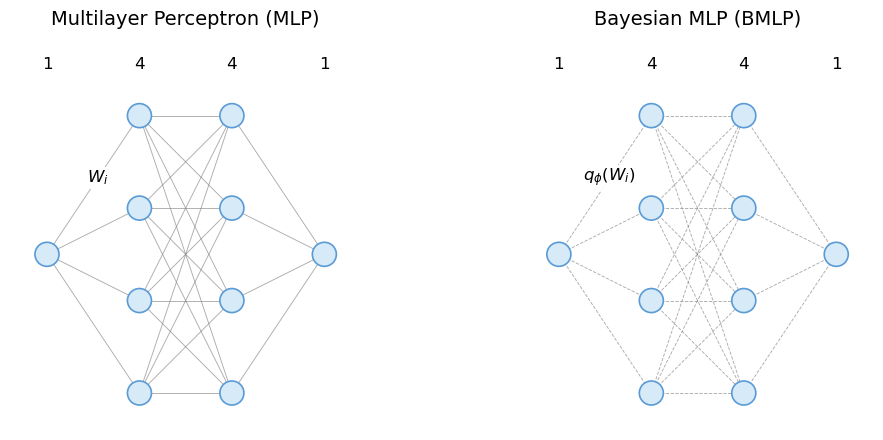

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# 网络及绘图参数
layers = [1, 4, 4, 1]
layer_spacing = 1.0
node_radius = 0.13
node_color = "#D6EAF8"
edge_color = "#5B9BD5"

def draw_network(ax, layers, bayesian=False):
    x_positions = np.arange(len(layers)) * layer_spacing
    positions = []

    # 1. 计算神经元坐标
    for i, n in enumerate(layers):
        y_positions = (n - 1) / 2 - np.arange(n)
        positions.append([(x_positions[i], y) for y in y_positions])

    # 2. 绘制连接线
    for i in range(len(layers) - 1):
        for x1, y1 in positions[i]:
            for x2, y2 in positions[i + 1]:
                ax.plot([x1, x2], [y1, y2],
                        color="gray", linewidth=0.65, alpha=0.65,
                        linestyle="--" if bayesian else "-",
                        zorder=1)

    # 3. 绘制浅蓝色神经元
    for layer in positions:
        for x, y in layer:
            ax.add_patch(Circle((x, y), radius=node_radius,
                                facecolor=node_color, edgecolor=edge_color,
                                linewidth=1.2, zorder=2))

    # 4. 在第一条连接线上标注权重
    x1, y1 = positions[0][0]
    x2, y2 = positions[1][0]
    t = 0.55
    x_label = x1 + t * (x2 - x1)
    y_label = y1 + t * (y2 - y1)

    weight_label = r"$q_{\phi}(W_i)$" if bayesian else r"$W_i$"
    ax.text(x_label, y_label, weight_label,
            fontsize=12, ha="center", va="center",
            color="black", zorder=4,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.95, pad=1.5))

    # 5. 每层神经元数量
    for i, n in enumerate(layers):
        ax.text(x_positions[i], 2.05, str(n),
                ha="center", va="center", fontsize=12)

    ax.set_xlim(-0.4, x_positions[-1] + 0.4)
    ax.set_ylim(-1.9, 2.3)
    ax.set_aspect("equal")
    ax.axis("off")

    title = "Bayesian MLP (BMLP)" if bayesian else "Multilayer Perceptron (MLP)"
    ax.set_title(title, fontsize=14, pad=12)

# 6. 绘图
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

draw_network(axes[0], layers, bayesian=False)
draw_network(axes[1], layers, bayesian=True)

plt.tight_layout(w_pad=2)
plt.savefig("MLP_vs_BMLP.pdf", bbox_inches="tight")
plt.savefig("MLP_vs_BMLP.png", dpi=300, bbox_inches="tight")
plt.show()

训练集: torch.Size([160, 1]) torch.Size([160, 1])
测试集: torch.Size([40, 1]) torch.Size([40, 1])


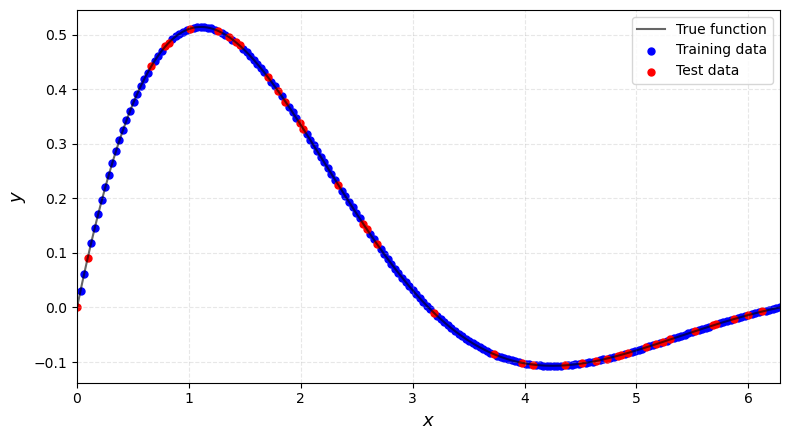

In [12]:
import torch

# 定义函数
x = np.linspace(0, 2 * np.pi, 1000)
y = np.sin(x) * np.exp(-0.5 * x)

# 1. 生成100个数据点
x_data = torch.linspace(0, 2 * torch.pi, 200).reshape(-1, 1)
y_data = torch.sin(x_data) * torch.exp(-0.5 * x_data)

# 2. 输入归一化到 [-1, 1]
X = x_data / torch.pi - 1
Y = y_data.clone()

# 3. 随机划分训练集和测试集（80:20）
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(X), generator=generator)
n_train = int(0.8 * len(X))

train_idx = indices[:n_train]
test_idx = indices[n_train:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print("训练集:", X_train.shape, Y_train.shape)
print("测试集:", X_test.shape, Y_test.shape)

# 4. 绘制数据分布
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, y, color="black", linewidth=1.5, alpha=0.6, label="True function")
ax.scatter(x_data[train_idx].numpy(), Y_train.numpy(), color="blue", s=25, label="Training data")
ax.scatter(x_data[test_idx].numpy(), Y_test.numpy(), color="red", s=25, label="Test data")

ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel(r"$y$", fontsize=13)
ax.set_xlim(0, 2 * np.pi)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 贝叶斯 MLP：先验分布与近似后验分布

- **先验 `prior`**：每一个权重、偏置预设为独立的 $p(\theta_j)=\mathcal N(0,1)$，不参与训练。
- **近似后验 `posterior`**：每一个权重、偏置使用 $q_\phi(\theta_j)=\mathcal N(\mu_j,\sigma_j^2)$；`posterior_*_mu`、`posterior_*_rho` 是可训练参数，$\sigma_j=\operatorname{softplus}(\rho_j)+10^{-6}$。
- **真实后验**：$p(\boldsymbol\theta\mid D)$ 一般无法精确计算；代码中的 `posterior` 指的是**近似后验**，不是解析求出的真实后验。
- **观测噪声 `observation_sigma`**：来自数据高斯似然 $p(y\mid u,\boldsymbol\theta)$，不是权重先验或后验的标准差。
- **训练目标**：负 ELBO = 平均 NLL + KL / 训练样本数。NLL 对从近似后验采样的权重取 Monte Carlo 平均，KL 比较近似后验与先验。


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, kl_divergence

# PyTorch 没有内置 nn.BayesianLinear；这里自定义一个均值场高斯变分贝叶斯层。
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # 近似后验的可训练参数：mu 与 rho（sigma 通过 softplus(rho) 得到）。
        self.posterior_weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.posterior_weight_rho = nn.Parameter(torch.full((out_features, in_features), -4.0))
        self.posterior_bias_mu = nn.Parameter(torch.zeros(out_features))
        self.posterior_bias_rho = nn.Parameter(torch.full((out_features,), -4.0))
        nn.init.xavier_uniform_(self.posterior_weight_mu)

    @property
    def posterior_weight_sigma(self):
        return F.softplus(self.posterior_weight_rho) + 1e-6

    @property
    def posterior_bias_sigma(self):
        return F.softplus(self.posterior_bias_rho) + 1e-6

    def forward(self, x):
        # 从近似后验 q_phi 采样一次权重和偏置；rsample() 支持重参数化梯度。Normal(loc, scale)是用来构造正态分布的
        posterior_weight = Normal(self.posterior_weight_mu, self.posterior_weight_sigma)
        posterior_bias = Normal(self.posterior_bias_mu, self.posterior_bias_sigma)
        sampled_weight = posterior_weight.rsample()
        sampled_bias = posterior_bias.rsample()
        return F.linear(x, sampled_weight, sampled_bias)

    def kl_loss(self):

        #自定义的先验分布，不参与训练，训练中不会更新
        prior_mu = 0.0
        prior_sigma = 0.5
        prior_weight = Normal(torch.full_like(self.posterior_weight_mu, prior_mu),
                              torch.full_like(self.posterior_weight_mu, prior_sigma))
        prior_bias = Normal(torch.full_like(self.posterior_bias_mu, prior_mu),
                            torch.full_like(self.posterior_bias_mu, prior_sigma))
        #后验分布的mu和sigma会随着训练不断的更新
        posterior_weight = Normal(self.posterior_weight_mu, self.posterior_weight_sigma)
        posterior_bias = Normal(self.posterior_bias_mu, self.posterior_bias_sigma)

        return kl_divergence(posterior_weight, prior_weight).sum() + kl_divergence(posterior_bias, prior_bias).sum()


# 2. 定义 1-4-4-1 贝叶斯 MLP。
class BMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = BayesianLinear(1, 4)
        self.layer2 = BayesianLinear(4, 4)
        self.layer3 = BayesianLinear(4, 1)

    def forward(self, x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        return self.layer3(x)

    def kl_loss(self):
        return self.layer1.kl_loss() + self.layer2.kl_loss() + self.layer3.kl_loss()


# 3. 初始化网络实例；bayesian_mlp 不是 PyTorch 内置函数。
torch.manual_seed(42)
bayesian_mlp = BMLP()

print(bayesian_mlp)
print("可训练参数数量:", sum(p.numel() for p in bayesian_mlp.parameters()))

BMLP(
  (layer1): BayesianLinear()
  (layer2): BayesianLinear()
  (layer3): BayesianLinear()
)
可训练参数数量: 66


Epoch [500/3000] | Train MSE: 0.00266074 | Test MSE: 0.00437684 | KL: 124.5326
Epoch [1000/3000] | Train MSE: 0.00069166 | Test MSE: 0.00114277 | KL: 132.1243
Epoch [1500/3000] | Train MSE: 0.00024604 | Test MSE: 0.00035318 | KL: 136.0441
Epoch [2000/3000] | Train MSE: 0.00007676 | Test MSE: 0.00018358 | KL: 138.5722
Epoch [2500/3000] | Train MSE: 0.00004990 | Test MSE: 0.00008949 | KL: 138.0320
Epoch [3000/3000] | Train MSE: 0.00005007 | Test MSE: 0.00013204 | KL: 136.6136


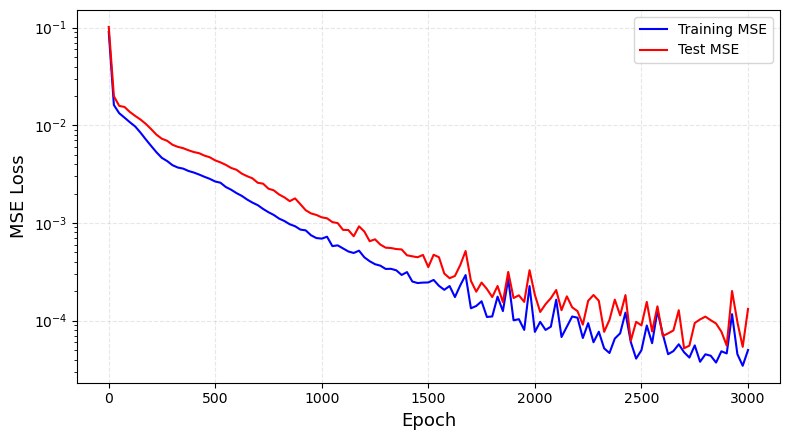

In [14]:
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. 训练参数
epochs = 3000
learning_rate = 0.005
observation_sigma = 0.03          # 高斯数据似然的观测噪声标准差（非权重的标准差），生成的数据是没有额外添加随机噪声的函数值所以要额外定义一个
train_mc_samples = 10             # 每次训练使用3次权重采样，每次计算训练损失时，从权重近似后验分布中采样多少次，采样次数较多通常能降低 Monte Carlo 估计的随机波动，但计算也会更慢
eval_mc_samples = 40              # 评估时使用40次权重采样，用于训练过程中的模型评估
record_every = 25

optimizer = optim.Adam(bayesian_mlp.parameters(), lr=learning_rate)

# 2. 保存训练历史
epoch_history = []
train_loss_history = []
test_loss_history = []
negative_elbo_history = []

# 3. 训练
for epoch in range(1, epochs + 1):
    bayesian_mlp.train()
    optimizer.zero_grad()

    # Gaussian NLL（省略常数项）
    nll = torch.stack([
        0.5 * ((bayesian_mlp(X_train) - Y_train) / observation_sigma).square().mean()
        for _ in range(train_mc_samples)
    ]).mean()

    # 近似后验与先验之间的KL散度
    kl = bayesian_mlp.kl_loss()

    # 负ELBO，按完整训练集的样本数归一化
    loss = nll + kl / len(X_train)

    loss.backward()
    optimizer.step()

    # 4. 评估训练集和测试集
    if epoch == 1 or epoch % record_every == 0:
        bayesian_mlp.eval()

        with torch.no_grad():
            train_pred = torch.stack([bayesian_mlp(X_train) for _ in range(eval_mc_samples)]).mean(dim=0)
            test_pred = torch.stack([bayesian_mlp(X_test) for _ in range(eval_mc_samples)]).mean(dim=0)

            train_mse = F.mse_loss(train_pred, Y_train).item()
            test_mse = F.mse_loss(test_pred, Y_test).item()

        epoch_history.append(epoch)
        train_loss_history.append(train_mse)
        test_loss_history.append(test_mse)
        negative_elbo_history.append(loss.item())

        if epoch % 500 == 0:
            print(f"Epoch [{epoch}/{epochs}] | Train MSE: {train_mse:.8f} | Test MSE: {test_mse:.8f} | KL: {kl.item():.4f}")

# 5. 绘制训练集和测试集MSE
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(epoch_history, train_loss_history, color="blue", linewidth=1.5, label="Training MSE")
ax.plot(epoch_history, test_loss_history, color="red", linewidth=1.5, label="Test MSE")

ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("MSE Loss", fontsize=13)
ax.set_yscale("log")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

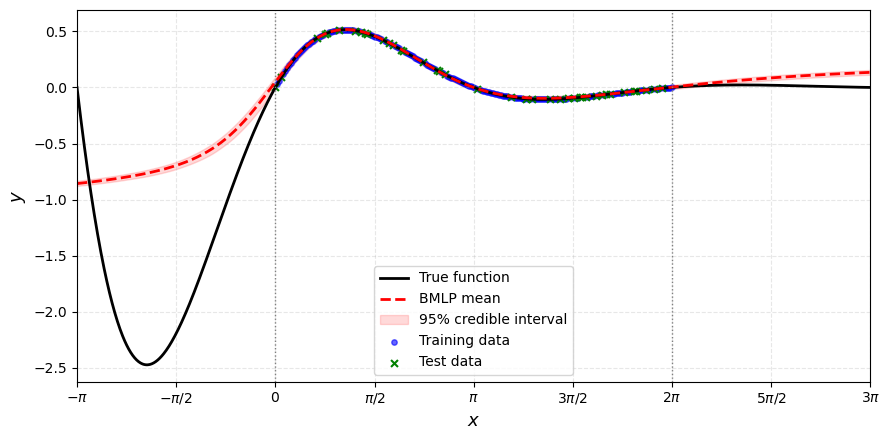

        x         True   Prediction         Std    Abs Error               95% Interval
-------------------------------------------------------------------------------------------
  -3.1416     0.000000    -0.856731    0.012599     0.856731 [ -0.88465,  -0.83306] OUT
  -1.5708    -2.193280    -0.694977    0.016857     1.498303 [ -0.72699,  -0.65821] OUT
   0.0000     0.000000     0.050488    0.024601     0.050488 [  0.00558,   0.10020] IN
   1.5708     0.455938     0.460886    0.014179     0.004948 [  0.43389,   0.48864] IN
   3.1416     0.000000     0.000090    0.010727     0.000090 [ -0.02002,   0.02111] IN
   4.7124    -0.094780    -0.088296    0.009974     0.006484 [ -0.10779,  -0.06864] IN
   6.2832    -0.000000     0.002878    0.010437     0.002878 [ -0.01686,   0.02435] IN
   7.8540     0.019703     0.084614    0.010796     0.064911 [  0.06363,   0.10696] OUT
   9.4248    -0.000000     0.133987    0.011018     0.133987 [  0.11149,   0.15571] OUT

Prediction Error:
MSE  = 0.33374

In [15]:
# 1. 生成绘图数据
x_plot = torch.linspace(-torch.pi, 3 * torch.pi, 1200).reshape(-1, 1)
X_plot = x_plot / torch.pi - 1
y_true = torch.sin(x_plot) * torch.exp(-0.5 * x_plot)

# 2. 从权重近似后验分布采样300次
bayesian_mlp.eval()

with torch.no_grad():
    posterior_predictions = torch.stack([
        bayesian_mlp(X_plot).squeeze(-1) for _ in range(300)
    ])

    # 预测均值与95%可信区间
    y_mean = posterior_predictions.mean(dim=0)
    y_lower = posterior_predictions.quantile(0.025, dim=0)
    y_upper = posterior_predictions.quantile(0.975, dim=0)

# 3. 绘制函数与可信区间
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(x_plot.numpy(), y_true.numpy(), color="black", linewidth=2, label="True function")
ax.plot(x_plot.numpy(), y_mean.numpy(), color="red", linewidth=2, linestyle="--", label="BMLP mean")

ax.fill_between(
    x_plot[:, 0].numpy(), y_lower.numpy(), y_upper.numpy(),
    color="red", alpha=0.15, label="95% credible interval"
)

# 训练数据与测试数据
ax.scatter(x_data[train_idx].numpy(), Y_train.numpy(), color="blue", s=15, alpha=0.6, label="Training data")
ax.scatter(x_data[test_idx].numpy(), Y_test.numpy(), color="green", s=25, marker="x", label="Test data")

# 标记训练区间
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.axvline(2 * np.pi, color="gray", linestyle=":", linewidth=1)

# 坐标轴
ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel(r"$y$", fontsize=13)
ax.set_xlim(-np.pi, 3 * np.pi)
ax.set_xticks(np.linspace(-np.pi, 3 * np.pi, 9))
ax.set_xticklabels([
    r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$",
    r"$\pi$", r"$3\pi/2$", r"$2\pi$", r"$5\pi/2$", r"$3\pi$"
])

ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# 4. 打印真实值、预测均值、标准差和绝对误差
x_check = torch.linspace(-torch.pi, 3 * torch.pi, 9).reshape(-1, 1)
y_check_true = torch.sin(x_check) * torch.exp(-0.5 * x_check)

# 从近似后验采样300次权重，得到模型输出的预测分布
bayesian_mlp.eval()
with torch.no_grad():
    posterior_check_samples = torch.stack([
        bayesian_mlp(x_check / torch.pi - 1).squeeze(-1) for _ in range(300)
    ])

    check_mean = posterior_check_samples.mean(dim=0)
    check_std = posterior_check_samples.std(dim=0)
    check_lower = posterior_check_samples.quantile(0.025, dim=0)
    check_upper = posterior_check_samples.quantile(0.975, dim=0)

# 计算绝对误差
true_values = y_check_true.squeeze(-1)
abs_error = torch.abs(check_mean - true_values)

print(f"{'x':>9} {'True':>12} {'Prediction':>12} {'Std':>11} {'Abs Error':>12} {'95% Interval':>26}")
print("-" * 91)

for i in range(len(x_check)):
    region = "IN" if 0 <= x_check[i].item() <= 2 * torch.pi else "OUT"

    print(
        f"{x_check[i].item():9.4f} "
        f"{true_values[i].item():12.6f} "
        f"{check_mean[i].item():12.6f} "
        f"{check_std[i].item():11.6f} "
        f"{abs_error[i].item():12.6f} "
        f"[{check_lower[i].item():9.5f}, {check_upper[i].item():9.5f}] "
        f"{region}"
    )

# 5. 计算整体误差
mse = torch.mean((check_mean - true_values)**2).item()
mae = torch.mean(abs_error).item()
rmse = np.sqrt(mse)

print("\nPrediction Error:")
print(f"MSE  = {mse:.8f}")
print(f"MAE  = {mae:.8f}")
print(f"RMSE = {rmse:.8f}")

# 6. 分别计算插值区间和外推区间误差
mask_inside = (x_plot[:, 0] >= 0) & (x_plot[:, 0] <= 2 * torch.pi)
mask_outside = ~mask_inside

for name, mask in [("Interpolation", mask_inside), ("Extrapolation", mask_outside)]:
    error = y_mean[mask] - y_true.squeeze(-1)[mask]
    print(f"{name:15s} MAE = {torch.mean(torch.abs(error)).item():.8f}")